# 🍷 TASK 2 · Wine Quality Prediction

## 🎯 Objective

Train and compare multiple machine learning classification models to predict the quality category of wine based on its physicochemical properties, such as acidity, density, sulphates, and alcohol content.

The original wine quality scores range from **3 to 8**. For classification, the scores are grouped into three categories:

- **Low Quality:** 3–4
- **Medium Quality:** 5–6
- **High Quality:** 7–8

The project also analyzes class imbalance and evaluates model performance using accuracy, precision, recall, F1-score, and confusion matrices.

## 🛠️ Tech Stack

- **Python**
- **Pandas**
- **NumPy**
- **Scikit-learn**
  - Random Forest Classifier
  - SGD Classifier
  - Support Vector Classifier (SVC)
- **Seaborn**
- **Matplotlib**
- **Jupyter Notebook**

## 📊 Project Workflow

1. Load and inspect the Wine Quality dataset
2. Analyze the distribution of wine quality scores
3. Perform Exploratory Data Analysis (EDA)
4. Visualize chemical feature distributions
5. Analyze feature correlations using a heatmap
6. Handle feature engineering and quality categorization
7. Perform stratified train-test splitting
8. Train Random Forest, SGD, and SVC classifiers
9. Evaluate model performance
10. Analyze confusion matrices
11. Identify important features using Random Forest
12. Compare all three models
13. Select the most suitable model for deployment

## 🏆 Final Result

Among the three tested classifiers, **Random Forest** achieved the best overall performance with **86.03% accuracy** and a **50.94% Macro F1-score**, making it the most suitable model for this wine quality classification task.

In [3]:
import pandas as pd
import numpy as np

print("Pandas and NumPy imported successfully!")

Pandas and NumPy imported successfully!


In [4]:
df = pd.read_csv("winequality-red.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [10]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (1143, 13)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               11

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [11]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Total rows: 1143
Total columns: 13
Total missing values: 0
Total duplicate rows: 0


In [15]:
quality_counts = df["quality"].value_counts().sort_index()

print("Wine Quality Distribution:")
print(quality_counts)

Wine Quality Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")

plt.show()

NameError: name 'plt' is not defined

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib and Seaborn imported successfully!")

Matplotlib and Seaborn imported successfully!


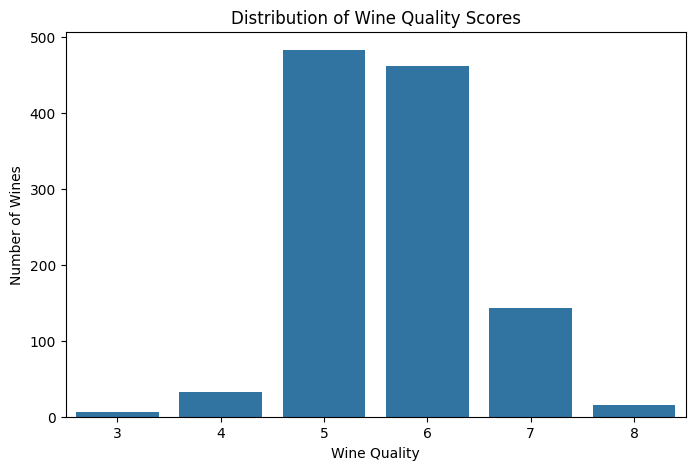

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")

plt.show()

Observation: The wine quality distribution is highly imbalanced. Quality scores 5 and 6 represent the majority of the dataset, while scores 3 and 8 have very few observations. This imbalance may cause classification models to favor the majority classes and perform poorly when predicting minority classes.

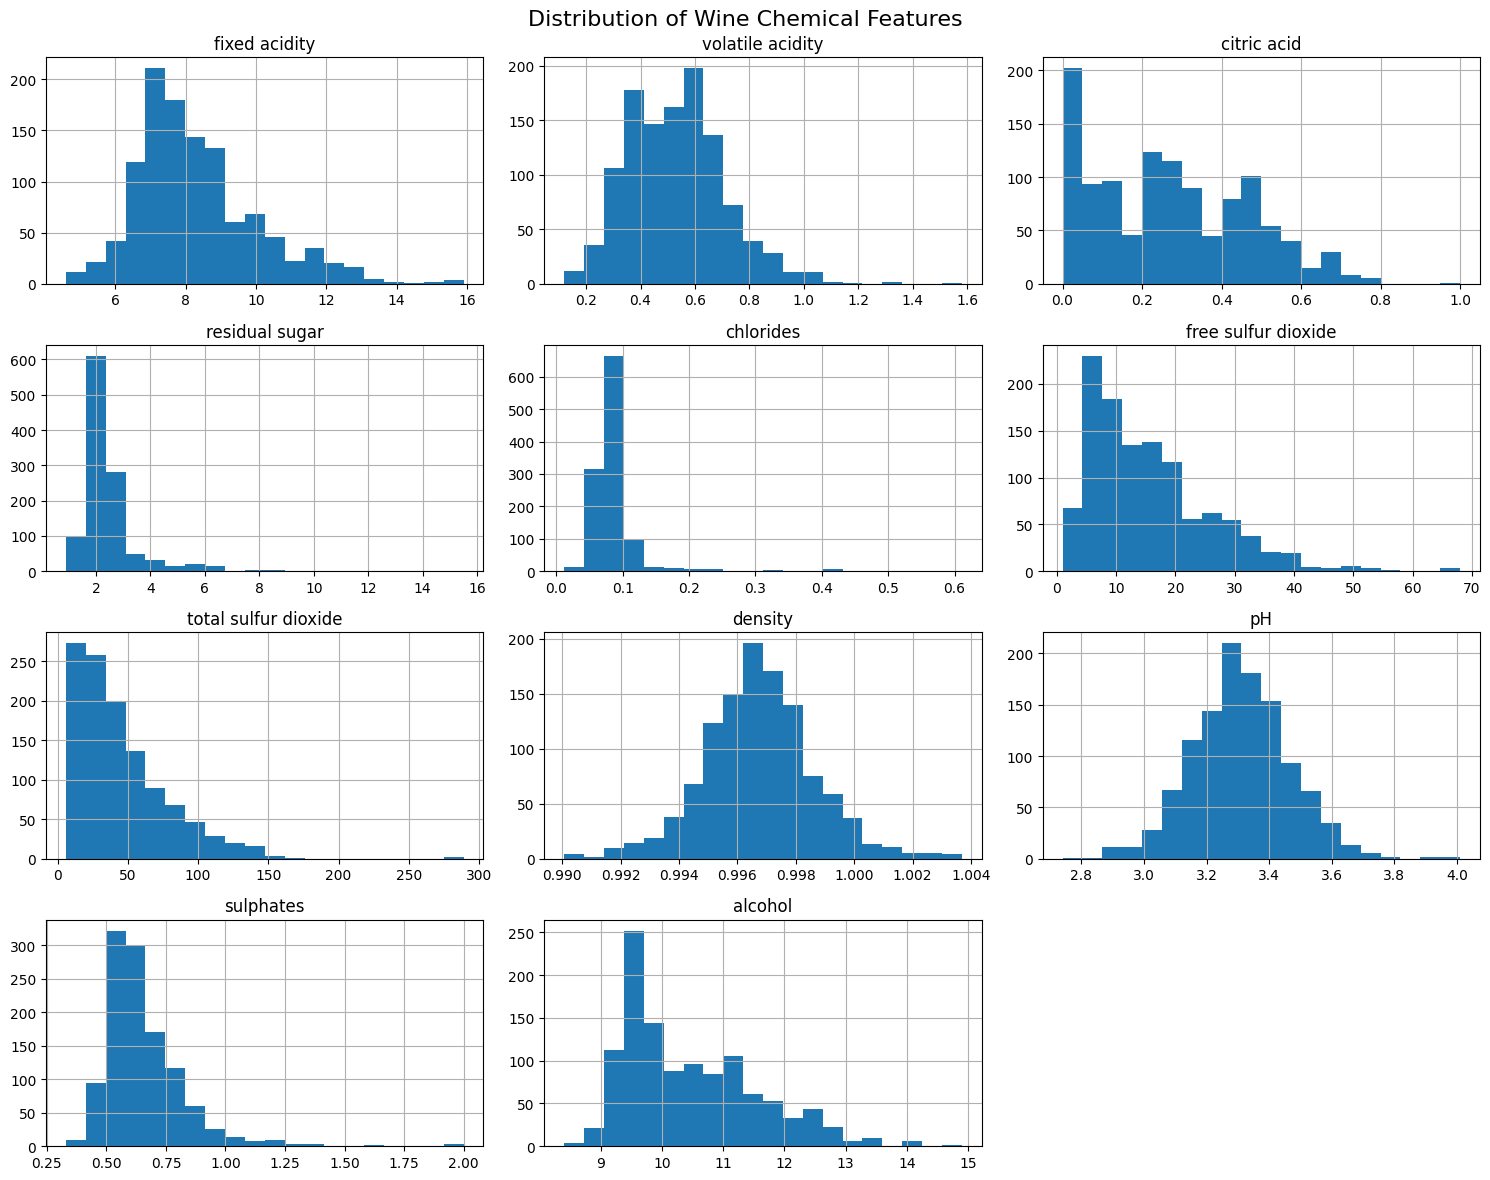

In [19]:
features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

df[features].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Wine Chemical Features", fontsize=16)

plt.tight_layout()
plt.show()

Observations: Most chemical features show non-normal or right-skewed distributions. Residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, sulphates, and alcohol have noticeable right skewness. Density and pH are more concentrated around their central values. The presence of skewed features and a few extreme values should be considered during preprocessing and model development.

In [ ]:
%pip install scikit-learn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("winequality-red.csv")

print(df.shape)

(1143, 13)


In [3]:
features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

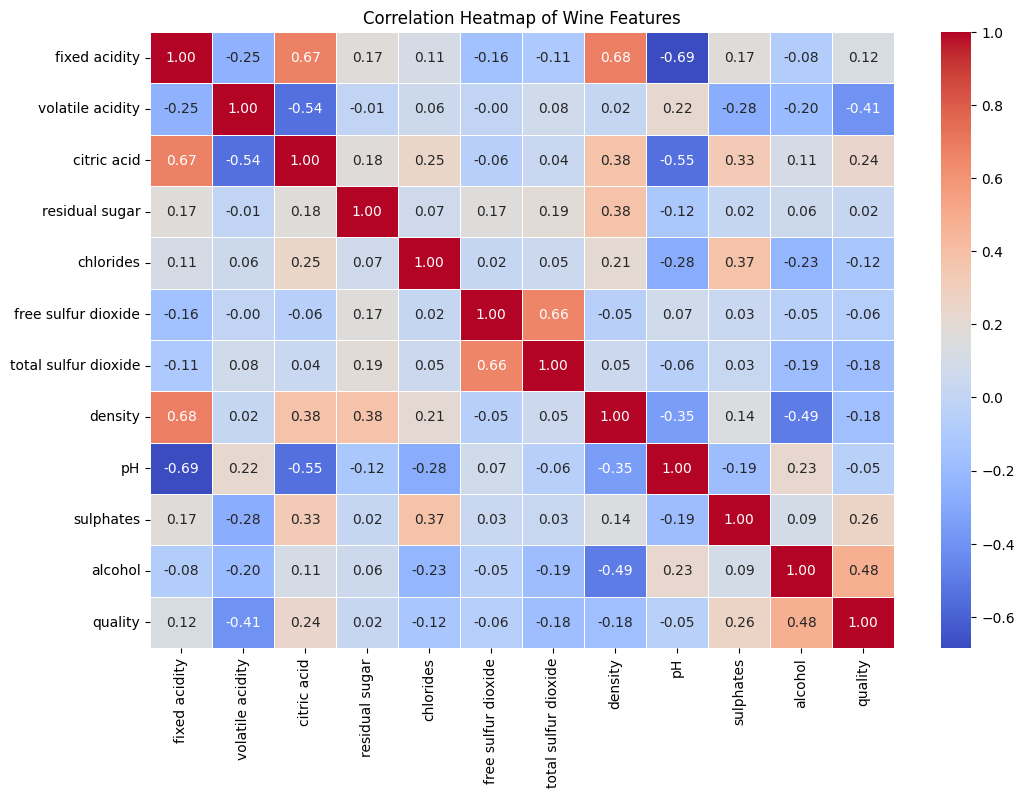

In [4]:
correlation_matrix = df[features + ["quality"]].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Features")
plt.show()

Alcohol shows the strongest positive correlation with quality (0.48), while volatile acidity shows the strongest negative correlation (-0.41). Some features also have strong relationships with each other, indicating feature dependencies. Therefore, multiple physicochemical properties are considered for wine quality classification.

In [5]:
def quality_category(score):
    if score <= 4:
        return "Low"
    elif score <= 6:
        return "Medium"
    else:
        return "High"

df["quality_category"] = df["quality"].apply(quality_category)

df[["quality", "quality_category"]].head(10)

,quality,quality_category
0,5,Medium
1,5,Medium
2,5,Medium
3,6,Medium
4,5,Medium
5,5,Medium
6,5,Medium
7,7,High
8,7,High
9,5,Medium


In [6]:
class_counts = df["quality_category"].value_counts()

print("Quality Category Distribution:")
print(class_counts)

Quality Category Distribution:
quality_category
Medium    945
High      159
Low        39
Name: count, dtype: int64


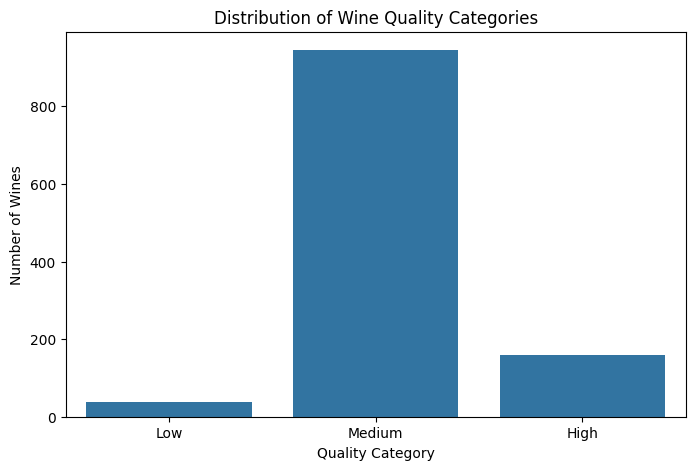

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality_category",
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Wine Quality Categories")
plt.xlabel("Quality Category")
plt.ylabel("Number of Wines")

plt.show()

### Feature Engineering Observation

The original wine quality scores were grouped into three categories:
Low (3–4), Medium (5–6), and High (7–8). This transformation simplifies the classification problem and provides more meaningful categories for prediction. However, the resulting classes remain imbalanced, with Medium-quality wines representing the majority of observations and Low-quality wines being underrepresented.

In [8]:
X = df[features]

y = df["quality_category"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1143, 11)
Target shape: (1143,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 914
Testing samples: 229


In [10]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
quality_category
Medium    0.827133
High      0.138950
Low       0.033917
Name: proportion, dtype: float64

Testing class distribution:
quality_category
Medium    0.825328
High      0.139738
Low       0.034934
Name: proportion, dtype: float64


In [11]:
print(class_counts)

quality_category
Medium    945
High      159
Low        39
Name: count, dtype: int64


In [12]:
print(y_train.value_counts())
print(y_test.value_counts())

quality_category
Medium    756
High      127
Low        31
Name: count, dtype: int64
quality_category
Medium    189
High       32
Low         8
Name: count, dtype: int64


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed!
Training data shape: (914, 11)
Testing data shape: (229, 11)


In [14]:
scaler.fit_transform(X_train)

array([[ 0.16007811, -0.85773295,  0.49790477, ..., -0.70985287,
        -0.56944959, -0.96888854],
       [-1.0113502 ,  0.9472371 , -1.00505206, ...,  0.86971019,
        -0.44916373,  0.25078907],
       [-0.30849321,  1.86360652, -0.0203562 , ..., -0.31496211,
        -1.17087889, -1.15653125],
       ...,
       [-0.01563613,  1.72476267, -1.31600864, ...,  0.07992866,
        -0.44916373,  0.53225313],
       [ 1.50722068, -0.80219541,  1.06799185, ..., -0.0517016 ,
         0.5732661 , -0.59360313],
       [-0.71849312,  0.47516801, -1.05687816, ..., -0.90729826,
        -1.05059303, -0.59360313]], shape=(914, 11))

In [15]:
scaler.transform(X_test)

array([[ 0.45293519, -1.74633359, -0.1240084 , ...,  0.6722648 ,
         1.29498127, -0.12449635],
       [-0.36706463, -1.52418343, -0.0203562 , ..., -1.03892851,
         0.81383782,  0.43843177],
       [-0.89420737,  1.30823111, -1.36783474, ...,  2.05438248,
         0.15226558, -0.49978177],
       ...,
       [ 1.68293493,  0.75285571,  1.48260063, ..., -0.90729826,
         0.33269437, -0.87506719],
       [-0.71849312,  0.97500587, -1.36783474, ...,  1.06715557,
        -0.62959252, -0.96888854],
       [-1.12849304,  0.19748031, -1.26418255, ...,  1.00134044,
         0.15226558, -0.87506719]], shape=(229, 11))

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 0.8602620087336245


In [17]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.56      0.61        32
         Low       0.00      0.00      0.00         8
      Medium       0.89      0.95      0.92       189

    accuracy                           0.86       229
   macro avg       0.52      0.50      0.51       229
weighted avg       0.83      0.86      0.84       229



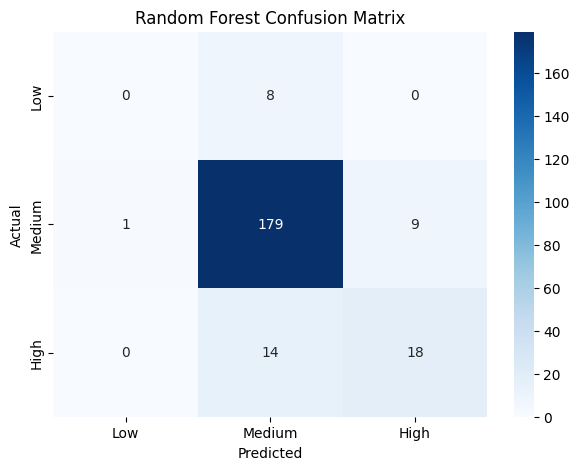

In [18]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Observation – Random Forest Confusion Matrix

The Random Forest model correctly classified 179 Medium-quality wines and 18 High-quality wines. However, 8 Low-quality wines were incorrectly classified as Medium, and 14 High-quality wines were also misclassified as Medium. Only 1 Medium-quality wine was incorrectly classified as Low, while no Low or High samples were predicted as the opposite extreme class. Overall, the model performs well in identifying the Medium class but has difficulty distinguishing Low and High quality wines from the Medium category.

In [19]:
X_train_scaled
X_test_scaled

array([[ 0.45293519, -1.74633359, -0.1240084 , ...,  0.6722648 ,
         1.29498127, -0.12449635],
       [-0.36706463, -1.52418343, -0.0203562 , ..., -1.03892851,
         0.81383782,  0.43843177],
       [-0.89420737,  1.30823111, -1.36783474, ...,  2.05438248,
         0.15226558, -0.49978177],
       ...,
       [ 1.68293493,  0.75285571,  1.48260063, ..., -0.90729826,
         0.33269437, -0.87506719],
       [-0.71849312,  0.97500587, -1.36783474, ...,  1.06715557,
        -0.62959252, -0.96888854],
       [-1.12849304,  0.19748031, -1.26418255, ...,  1.00134044,
         0.15226558, -0.87506719]], shape=(229, 11))

In [20]:
sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

sgd_predictions = sgd_model.predict(X_test_scaled)

print(
    "SGD Accuracy:",
    accuracy_score(y_test, sgd_predictions)
)

SGD Accuracy: 0.8209606986899564


In [24]:
print("SGD Classification Report:")

print(
    classification_report(
        y_test,
        sgd_predictions
    )
)


classification_report(
    y_test,
    sgd_predictions,
    zero_division=0
)

SGD Classification Report:
              precision    recall  f1-score   support

        High       0.48      0.44      0.46        32
         Low       0.00      0.00      0.00         8
      Medium       0.87      0.92      0.89       189

    accuracy                           0.82       229
   macro avg       0.45      0.45      0.45       229
weighted avg       0.79      0.82      0.80       229



C:\Users\PAGID\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PAGID\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PAGID\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


'              precision    recall  f1-score   support\n\n        High       0.48      0.44      0.46        32\n         Low       0.00      0.00      0.00         8\n      Medium       0.87      0.92      0.89       189\n\n    accuracy                           0.82       229\n   macro avg       0.45      0.45      0.45       229\nweighted avg       0.79      0.82      0.80       229\n'

### SGD Model Observation

The SGD classifier achieved an accuracy of 82%. However, its performance was strongly influenced by class imbalance. The model performed well on the majority Medium class, achieving a recall of 0.92, but it failed to correctly identify the Low class, resulting in zero precision, recall, and F1-score for that class. The macro-average F1-score of 0.45 indicates that the model's performance across all classes is considerably weaker than its overall accuracy suggests.

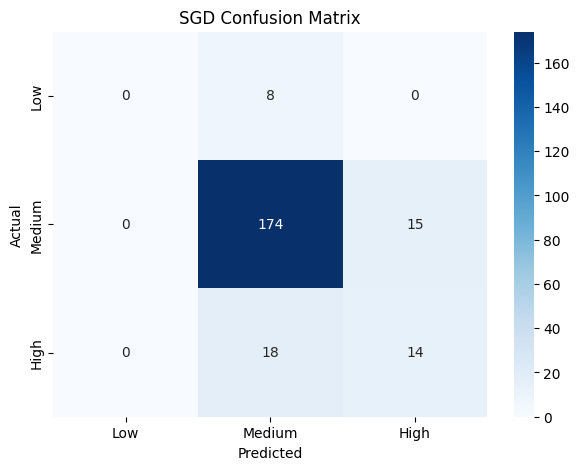

In [22]:
sgd_cm = confusion_matrix(
    y_test,
    sgd_predictions,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("SGD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Observation – SGD Confusion Matrix

> The SGD model correctly classified **174 Medium-quality wines** and **14 High-quality wines**. However, **8 Low-quality wines were misclassified as Medium**, while **15 Medium-quality wines were misclassified as High**. Additionally, **18 High-quality wines were incorrectly classified as Medium**. The model did not correctly identify any Low-quality wines, indicating difficulty in recognizing the Low class. Overall, the SGD model performs better on the Medium class but shows weaker performance for Low and High-quality wines.


In [25]:
svc_model = SVC(
    kernel="rbf",
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

svc_predictions = svc_model.predict(X_test_scaled)

print(
    "SVC Accuracy:",
    accuracy_score(y_test, svc_predictions)
)

SVC Accuracy: 0.8427947598253275


In [26]:
print("SVC Classification Report:")

print(
    classification_report(
        y_test,
        svc_predictions,
        zero_division=0
    )
)

SVC Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.25      0.36        32
         Low       0.00      0.00      0.00         8
      Medium       0.85      0.98      0.91       189

    accuracy                           0.84       229
   macro avg       0.51      0.41      0.42       229
weighted avg       0.80      0.84      0.80       229



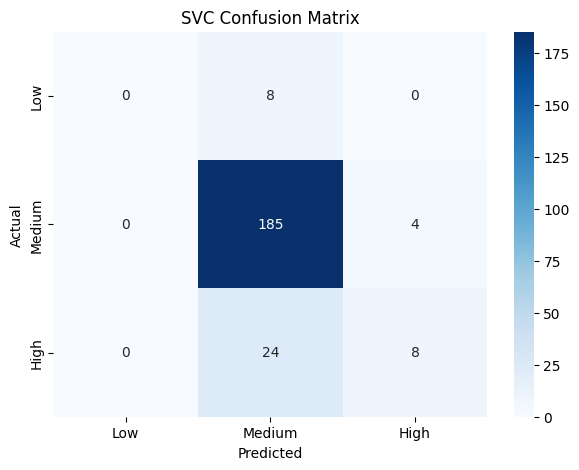

In [27]:
svc_cm = confusion_matrix(
    y_test,
    svc_predictions,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Observation – SVC Confusion Matrix

> The SVC model correctly classified **185 Medium-quality wines** and **8 High-quality wines**. However, **8 Low-quality wines were misclassified as Medium**, while **4 Medium-quality wines were misclassified as High**. Additionally, **24 High-quality wines were incorrectly classified as Medium**. The model did not correctly identify any Low-quality wines, showing difficulty in recognizing the minority Low class. Overall, SVC performs very well in identifying the **Medium class**, but it tends to classify High-quality wines as Medium.


In [28]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.155432
1,volatile acidity,0.121587
9,sulphates,0.104312
2,citric acid,0.092809
7,density,0.088104
4,chlorides,0.087150
0,fixed acidity,0.080798
6,total sulfur dioxide,0.073440
3,residual sugar,0.073439
8,pH,0.065370


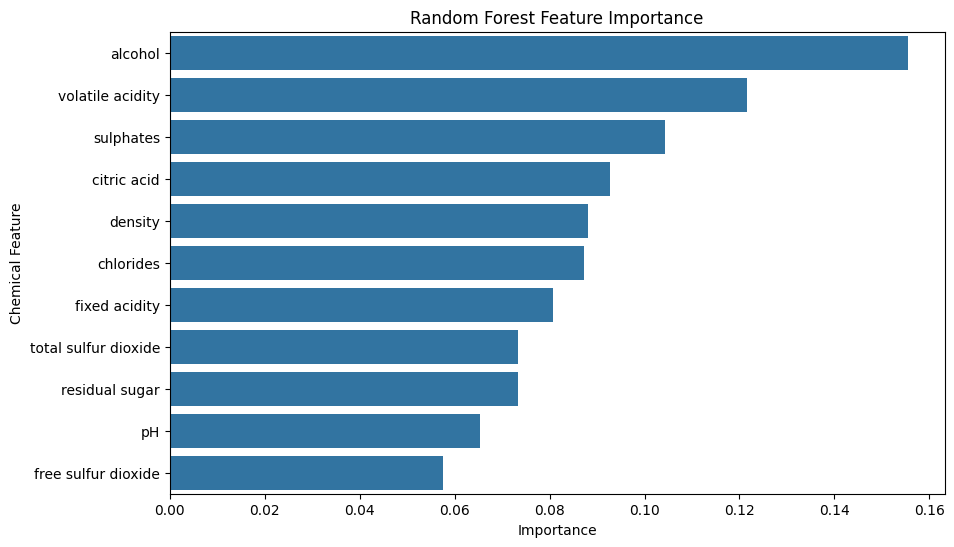

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Chemical Feature")

plt.show()

## Random Forest Feature Importance

In [30]:
models = {
    "Random Forest": rf_predictions,
    "SGD": sgd_predictions,
    "SVC": svc_predictions
}

comparison = []

for model_name, predictions in models.items():
    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    comparison.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Random Forest,0.860262,0.519071,0.503197,0.509373,0.842872
1,SGD,0.820961,0.450920,0.452712,0.451206,0.802481
2,SVC,0.842795,0.506400,0.409612,0.424989,0.802960


In [31]:
best_model = comparison_df.loc[
    comparison_df["Macro F1"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model              Random Forest
Accuracy                0.860262
Macro Precision         0.519071
Macro Recall            0.503197
Macro F1                0.509373
Weighted F1             0.842872
Name: 0, dtype: object


In [32]:
comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Random Forest,0.860262,0.519071,0.503197,0.509373,0.842872
1,SGD,0.820961,0.450920,0.452712,0.451206,0.802481
2,SVC,0.842795,0.506400,0.409612,0.424989,0.802960


## Conclusion

In this project, three classification algorithms—Random Forest, SGD Classifier, and Support Vector Classifier (SVC)—were trained to predict wine quality categories based on physicochemical properties.

The original wine quality scores were transformed into three categories: Low (3–4), Medium (5–6), and High (7–8). The dataset showed significant class imbalance, with Medium-quality wines representing the majority of observations and Low-quality wines being considerably underrepresented.

The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrices. Since the dataset was imbalanced, Macro F1-score was given particular importance because it gives equal consideration to each quality category.

Among the three models, Random Forest performed the best, achieving an accuracy of 86.03% and a Macro F1-score of 50.94%. It also achieved the highest Macro Precision (51.91%), Macro Recall (50.32%), and Weighted F1-score (84.29%).

SGD achieved an accuracy of 82.10%, while SVC achieved 84.28%. Although both models achieved reasonable accuracy, their Macro F1-scores were lower than Random Forest, indicating weaker overall performance across the three classes.

Therefore, Random Forest is the most suitable model for deployment among the three tested algorithms. Its stronger overall performance and ability to handle nonlinear relationships between physicochemical features make it a suitable choice for this wine quality classification task.

However, the relatively lower Macro F1-score compared with the overall accuracy indicates that class imbalance remains a challenge, particularly for the minority quality categories. Future improvements could include class weighting, oversampling techniques such as SMOTE, and additional hyperparameter tuning.